**Imports and system functions**

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import integrate

In [4]:
def mu1(qq, q_c, q_max, mu_max):
    if isinstance(qq, np.ndarray):
        return np.array([mu1(q, q_c, q_max, mu_max) for q in qq])
    if qq < q_c:
        return mu_max * qq / q_c
    elif qq <= q_max:
        return mu_max
    else:
        raise Exception("Queue overflow in mu1!")

def f_fair1(qq, q_m, beta):
    if isinstance(qq, np.ndarray):
        return np.array([f_fair1(q, q_m, beta) for q in qq])
    if qq < q_m:
        return beta * qq
    elif qq <= 2 * q_m:
        return beta * (2 * q_m - qq)
    else:
        return 0

def alpha(qq, a_slope, a_intcp, q_max):
    if isinstance(qq, np.ndarray):
        return np.array([alpha(q, a_slope, a_intcp, q_max) for q in qq])
    return max(a_intcp + qq * a_slope, 0) if 0 <= qq < q_max else 0

def dX_dt(X, t, q_c, q_max, mu_max, q_m, beta, a_slope, a_intcp):
    Rdot = K_R - f_fair1(X[1], q_m, beta) * X[0] - alpha(X[1], a_slope, a_intcp, q_max) * X[0]
    qdot = alpha(X[1], a_slope, a_intcp, q_max) * X[0] - mu1(X[1], q_c, q_max, mu_max)
    return np.array([Rdot, qdot])


**Parameters and alpha calibration**

In [6]:
from scipy.optimize import brentq

q_m = 45
q1, q2 = 35, 85
K_R = 10
mu_max = 5
q_c, q_max = 55, 100
beta = 0.001

if q2 >= 2 * q_m:
    raise Exception("Second fixed point outside the domain of price function!")

p1, p2 = beta * q1, beta * (2 * q_m - q2)

mu_star1 = mu1(q1, q_c, q_max, mu_max)
mu_star2 = mu1(q2, q_c, q_max, mu_max)
f_star1  = f_fair1(q1, q_m, beta)
f_star2  = f_fair1(q2, q_m, beta)

alpha_star1 = (p1 * mu_star1) / (K_R - mu_star1)
alpha_star2 = (p2 * mu_star2) / (K_R - mu_star2)
alpha_slope = (alpha_star2 - alpha_star1) / (q2 - q1)
alpha_intcp = alpha_star1 - q1 * alpha_slope

# Shared curve arrays
qs      = np.linspace(0, q_max, 501)
f_q     = f_fair1(qs, q_m, beta)
alpha_q = alpha(qs, alpha_slope, alpha_intcp, q_max)
mu_q    = mu1(qs, q_c, q_max, mu_max)

qs_hatch   = np.linspace(q_m, q2, 500)
f_qh       = f_fair1(qs_hatch, q_m, beta)
alpha_qh   = alpha(qs_hatch, alpha_slope, alpha_intcp, q_max)
mu_qh      = mu1(qs_hatch, q_c, q_max, mu_max)

Rdag  = K_R / alpha(0, alpha_slope, alpha_intcp, q_max)
qdag  = 54.254742545  # hardcoded

# qdag2: where eta2 nullcline comes back down to Rdag
# i.e., K_R / (alpha(q) + f(q)) = Rdag  =>  alpha(q) + f(q) = alpha(0)
def eta2_eq(q):
    return alpha(q, alpha_slope, alpha_intcp, q_max) + f_fair1(q, q_m, beta) - alpha(0, alpha_slope, alpha_intcp, q_max)

qdag2 = brentq(eta2_eq, q_m + 0.01, 2 * q_m)
print(f"qdag  = {qdag:.9f}")
print(f"qdag2 = {qdag2:.9f}")  # should recover 73.369565215

qs_hatch_h = np.linspace(qdag, q2, 500)
f_qh_h     = f_fair1(qs_hatch_h, q_m, beta)
alpha_qh_h = alpha(qs_hatch_h, alpha_slope, alpha_intcp, q_max)
mu_qh_h    = mu1(qs_hatch_h, q_c, q_max, mu_max)
eta2_h     = [max(Rdag, i) for i in K_R / (alpha_qh_h + f_qh_h)]

qdag  = 54.254742545
qdag2 = 73.369565217


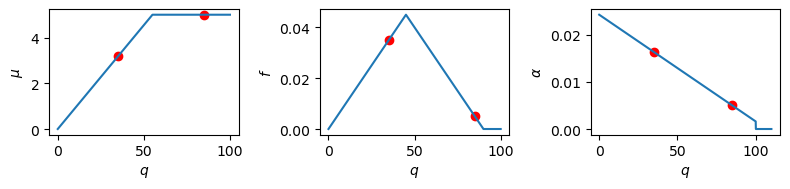

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(8, 2))

axes[0].plot(qs, mu_q)
axes[0].scatter([q1, q2], [mu_star1, mu_star2], c='red')
axes[0].set_xlabel(r'$q$'); axes[0].set_ylabel(r'$\mu$')

axes[1].plot(qs, f_q)
axes[1].scatter([q1, q2], [f_star1, f_star2], c='red')
axes[1].set_xlabel(r'$q$'); axes[1].set_ylabel(r'$f$')

axes[2].plot(np.linspace(0, q_max + 10, 1000),
             alpha(np.linspace(0, q_max + 10, 1000), alpha_slope, alpha_intcp, q_max))
axes[2].scatter([q1, q2], [alpha_star1, alpha_star2], c='red')
axes[2].set_xlabel(r'$q$'); axes[2].set_ylabel(r'$\alpha$')

plt.tight_layout()
plt.show()

**Phase portrait and trajectories**

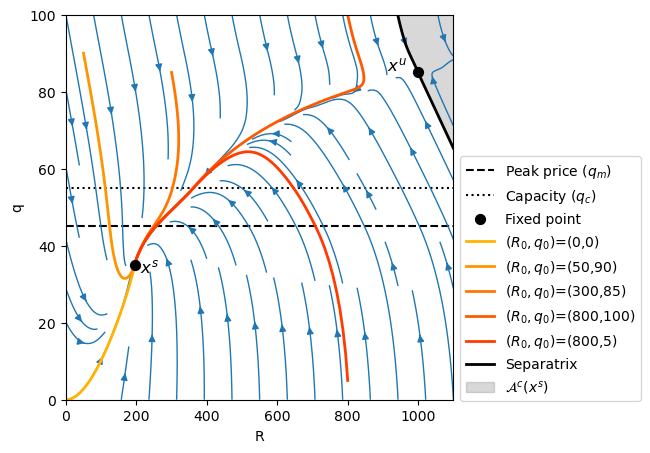

In [9]:
rmax, qmax_pp = 1100, 100
nb_points = 30

x_pp = np.linspace(0, rmax, nb_points)
y_pp = np.linspace(0, qmax_pp, nb_points)
Rs, Qs = np.meshgrid(x_pp, y_pp)

DR, DQ = dX_dt([Rs, Qs], 0, q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp)
M = np.hypot(DR, DQ)
M[M == 0] = 1.
DR /= M; DQ /= M

traj_values = [[0, 0], [50, 90], [300, 85], [800, 99.9],
               [800, 5], [941.86, 99.99], [1100, 65.325]]
t_traj = np.linspace(0, 400, 1000)
vcolors = plt.cm.autumn_r(np.linspace(0.3, 1., len(traj_values)))
vcolors[-1] = vcolors[-2] = [0, 0, 0, 1]

strix1 = integrate.odeint(dX_dt, traj_values[-2], t_traj,
                          args=(q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp))
strix2 = integrate.odeint(dX_dt, traj_values[-1], t_traj,
                          args=(q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp))
strixX_pp = np.concatenate((strix1[:, 0], strix2[:, 0][::-1]))
strixY_pp = np.concatenate((strix1[:, 1], strix2[:, 1][::-1]))

plt.figure(figsize=(5, 5))
plt.plot([0, rmax], [q_m, q_m], 'k--', label=r'Peak price ($q_m$)')
plt.plot([0, rmax], [q_c, q_c], 'k:',  label=r'Capacity ($q_c$)')
plt.streamplot(Rs, Qs, DR, DQ, density=[0.5, 5], linewidth=1)
plt.scatter([(K_R-mu_star1)/p1, (K_R-mu_star2)/p2], [q1, q2],
            c='k', marker='o', s=50, zorder=3, label='Fixed point')

for v, col in zip(traj_values, vcolors):
    X = integrate.odeint(dX_dt, v, t_traj,
                         args=(q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp))
    lbl = (r'$(R_0,q_0)$=(%.f,%.f)' % (v[0], v[1]) if v[0] < 940
           else ('Separatrix' if v[0] < 1100 else ''))
    plt.plot(X[:, 0], X[:, 1], lw=2, color=col, label=lbl)

plt.fill_between(strixX_pp, strixY_pp, 100 * np.ones(strixY_pp.shape),
                 color='gray', alpha=0.3, label=r'$\mathcal{A}^c(x^s)$')

plt.text(210, 33, '$x^s$', fontsize=12, fontweight='bold')
plt.text(912, 85.5, '$x^u$', fontsize=12, fontweight='bold')
plt.xlabel('R'); plt.ylabel('q')
plt.xlim(0, rmax); plt.ylim(0, qmax_pp)
plt.legend(bbox_to_anchor=(1, 0.65))
plt.savefig('figures/phaseplane2D.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

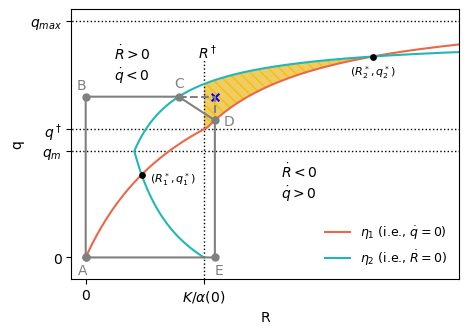

In [10]:
mpl.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'text.usetex': False})

arbR, arbQ = 450, 68

# Safe divisions
with np.errstate(divide='ignore', invalid='ignore'):
    eta1       = np.where(alpha_q          > 0, mu_q / alpha_q,              np.nan)
    eta1_hatch = np.where(alpha_qh_h       > 0, mu_qh_h / alpha_qh_h,        np.nan)
    eta2       = np.where(alpha_q + f_q    > 0, K_R / (alpha_q + f_q),       np.nan)

plt.figure(figsize=(5, 3.5))

# Reference lines
for yval in [q_max, q_m, qdag]:
    plt.plot([-100, 1500], [yval, yval], ':k', lw=1)
plt.plot([Rdag, Rdag], [-9, qdag2 + 10], ':k', lw=1)
plt.text(Rdag - 20, qdag2 + 11, r'$R^\dagger$')

# Nullclines
plt.plot(eta1, qs, c='#EA6849', label=r'$\eta_1$ (i.e., $\dot{q}=0$)')
plt.plot(eta2, qs, c='#22B6BA', label=r'$\eta_2$ (i.e., $\dot{R}=0$)')

# Hatched region
plt.fill_betweenx(qs_hatch_h, eta1_hatch, eta2_h,
                  hatch='\\\\\\', edgecolor='#FCBC06', facecolor='#EECD64', linewidth=0.0)

# Region labels
plt.text(100, 75, '$\\dot{R}>0$\n$\\dot{q}<0$')
plt.text(680, 25, '$\\dot{R}<0$\n$\\dot{q}>0$')

# Equilibria
plt.scatter([(K_R - mu_star1) / p1], [q1], s=15, c='k', zorder=3)
plt.scatter([mu_star2 / alpha_star2],  [q2], s=15, c='k', zorder=3)
plt.text(225, 32, r'$(R_1^*, q_1^*)$', fontsize=8)
plt.text(920, 77, r'$(R_2^*, q_2^*)$', fontsize=8)

# Arbitrary trajectory
plt.plot([0, 0, K_R/(alpha_q[340]+f_q[340]), arbR, arbR, 0],
         [0, arbQ, qs[340], qs[290], 0, 0], c='gray', marker='o', markersize=5)
plt.plot([K_R/(alpha_q[340]+f_q[340]), arbR, arbR],
         [qs[340], arbQ, qs[290]], c='gray', ls='--')
plt.scatter([arbR], [arbQ], marker='x', s=30, c='b')

# Point labels
for txt, x, y in [('A', -28, -7), ('B', -30, arbQ+3),
                  ('C', arbR-140, qs[340]+4), ('E', arbR, -7)]:
    plt.text(x, y, txt, c='gray')
plt.text(mu_q[290]/alpha_q[290]+30, arbQ-12, 'D', c='gray')

plt.xlabel('R'); plt.ylabel('q')
plt.yticks([0, q_m, qdag, 100], [0, r'$q_m$', r'$q^\dagger$', r'$q_{max}$'])
plt.xticks([0, K_R/(alpha_q[0]+f_q[0])], [0, r'$K/\alpha(0)$'])
plt.xlim([-50, 1300]); plt.ylim([-9, 105])
plt.legend(fontsize=9, frameon=False)
plt.savefig('figures/Fig2.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

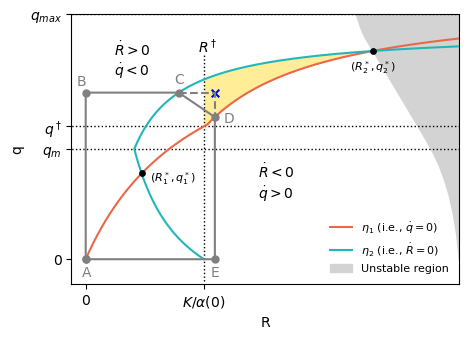

In [11]:
with np.errstate(divide='ignore', invalid='ignore'):
    eta1       = np.where(alpha_q    > 0, mu_q    / alpha_q,       np.nan)
    eta1_hatch = np.where(alpha_qh_h > 0, mu_qh_h / alpha_qh_h,   np.nan)
    eta2       = np.where(alpha_q + f_q > 0, K_R / (alpha_q + f_q), np.nan)
    D_label_x  = mu_q[290] / alpha_q[290] if alpha_q[290] > 0 else np.nan

# Strix computation (shared with Fig4)
t_strix    = np.linspace(0, 170, 500)
strix_vals = [[941.86, 100], [1300, 0.0]]
strix1 = integrate.odeint(dX_dt, strix_vals[0], t_strix,
                          args=(q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp))
strix2 = integrate.odeint(dX_dt, strix_vals[1], t_strix,
                          args=(q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp))
strixX = np.concatenate((strix1[:, 0], strix2[:, 0][::-1]))
strixY = np.concatenate((strix1[:, 1], strix2[:, 1][::-1]))

plt.figure(figsize=(5, 3.5))

for yval in [q_max, q_m, qdag]:
    plt.plot([-100, 1500], [yval, yval], ':k', lw=1)
plt.plot([Rdag, Rdag], [-9, qdag2+10], ':k', lw=1)
plt.text(Rdag-20, qdag2+11, r'$R^\dagger$')

plt.plot(eta1, qs, c='#EA6849', label=r'$\eta_1$ (i.e., $\dot{q}=0$)')
plt.plot(eta2, qs, c='#22B6BA', label=r'$\eta_2$ (i.e., $\dot{R}=0$)')

plt.fill_betweenx(qs_hatch_h, eta1_hatch, eta2_h,
                  edgecolor='#FdBd16', facecolor='#FFEE97', linewidth=0.0)

plt.text(100, 75, '$\\dot{R}>0$\n$\\dot{q}<0$')
plt.text(600, 25, '$\\dot{R}<0$\n$\\dot{q}>0$')

plt.scatter([(K_R - mu_star1) / p1], [q1], s=15, c='k', zorder=3)
plt.scatter([mu_star2 / alpha_star2],  [q2], s=15, c='k', zorder=3)
plt.text(225, 32, r'$(R_1^*, q_1^*)$', fontsize=8)
plt.text(920, 77, r'$(R_2^*, q_2^*)$', fontsize=8)

plt.plot([0, 0, K_R/(alpha_q[340]+f_q[340]), arbR, arbR, 0],
         [0, arbQ, qs[340], qs[290], 0, 0], c='gray', marker='o', markersize=5)
plt.plot([K_R/(alpha_q[340]+f_q[340]), arbR, arbR],
         [qs[340], arbQ, qs[290]], c='gray', ls='--')
plt.scatter([arbR], [arbQ], marker='x', s=30, c='b')

for txt, x, y in [('A', -15, -7), ('B', -30, arbQ+3),
                  ('C', arbR-140, qs[340]+4), ('E', arbR-15, -7)]:
    plt.text(x, y, txt, c='gray')
plt.text(D_label_x + 30, arbQ-12, 'D', c='gray')

plt.fill_between(strixX, strixY, 100 * np.ones(strixY.shape),
                 color='lightgray', zorder=1, label='Unstable region')

plt.xlabel('R'); plt.ylabel('q')
plt.yticks([0, q_m, qdag, 100], [0, r'$q_m$', r'$q^\dagger$', r'$q_{max}$'])
plt.xticks([0, K_R/(alpha_q[0]+f_q[0])], [0, r'$K/\alpha(0)$'])
plt.xlim([-50, 1300]); plt.ylim([-10, 100])
plt.legend(fontsize=8, frameon=False)
plt.savefig('figures/Fig4_printsafe.png', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

**Chattering surface figure**

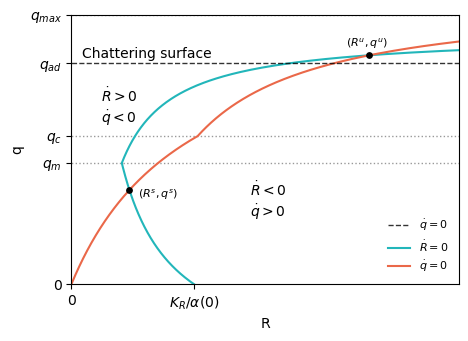

In [13]:
with np.errstate(divide='ignore', invalid='ignore'):
    eta1 = np.where(alpha_q      > 0, mu_q / alpha_q,          np.nan)
    eta2 = np.where(alpha_q + f_q > 0, K_R / (alpha_q + f_q),  np.nan)

plt.figure(figsize=(5, 3.5))

for yval, ls in [(q_max, ':'), (q_c, ':'), (q_m, ':')]:
    plt.plot([-100, 1500], [yval, yval], ls+'k', lw=1, alpha=0.4)
plt.plot([-100, 1500], [82, 82], '--k', lw=1, alpha=0.8, zorder=3, label=r'$\dot{q}=0$')

plt.plot(eta2, qs, c='#22B6BA', label=r'$\dot{R}=0$')
plt.plot(eta1, qs, c='#EA6849', label=r'$\dot{q}=0$')

plt.text(100, 60, '$\\dot{R}>0$\n$\\dot{q}<0$')
plt.text(600, 25, '$\\dot{R}<0$\n$\\dot{q}>0$')
plt.text(35, 84, 'Chattering surface')

plt.scatter([(K_R - mu_star1) / p1], [q1], s=15, c='k', zorder=3)
plt.scatter([mu_star2 / alpha_star2],  [q2], s=15, c='k', zorder=3)
plt.text(225, 32, r'$(R^s, q^s)$', fontsize=8)
plt.text(920, 88, r'$(R^u, q^u)$', fontsize=8)

plt.xlabel('R'); plt.ylabel('q')
plt.yticks([0, q_m, q_c, 82, 100], [0, r'$q_m$', r'$q_c$', r'$q_{ad}$', r'$q_{max}$'])
plt.xticks([0, K_R/(alpha_q[0]+f_q[0])], [0, r'$K_R/\alpha(0)$'])
plt.xlim([0, 1300]); plt.ylim([0, 100])
plt.legend(fontsize=8, frameon=False)
plt.savefig('figures/ChatteringSurface.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()